<a href="https://colab.research.google.com/github/rikesh28/Credit_Card_Fraud_Detection/blob/main/notebooks/1)%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
transaction_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_transaction.csv.zip')

In [ ]:
transaction_data.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(f'Shape: {transaction_data.shape}')
print(f'Columns (first 10): {transaction_data.columns.tolist()[:10]}')
print(f'\nFraud Distribution:')
print(transaction_data['isFraud'].value_counts())
print(f'Fraud Rate: {transaction_data["isFraud"].mean()*100:.2f}%')

In [ ]:
# check dtypes and missingness for the features I'll probably care about
important_cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
                  'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
                  'addr1', 'addr2', 'dist1', 'dist2',
                  'P_emaildomain', 'R_emaildomain']

for col in important_cols:
    if col in transaction_data.columns:
        print(f"  {col}: {transaction_data[col].dtype}, {transaction_data[col].isnull().sum()} missing")

In [ ]:
# fraud rate breakdowns
print('Fraud by Product:')
print(transaction_data.groupby('ProductCD')['isFraud'].agg(['mean','count']))

print('\nFraud by Card Type:')
print(transaction_data.groupby('card4')['isFraud'].agg(['mean','count']))

print('\nTransaction Amount Stats:')
print(transaction_data.groupby('isFraud')['TransactionAmt'].describe())

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

fraud_by_product = transaction_data.groupby('ProductCD')['isFraud'].mean() * 100
fraud_by_product.plot(kind='bar', ax=axes[0])
axes[0].set_title('Fraud Rate by Product')
axes[0].set_ylabel('Fraud Rate (%)')

fraud_by_card = transaction_data.groupby('card4')['isFraud'].mean() * 100
fraud_by_card.plot(kind='bar', ax=axes[1])
axes[1].set_title('Fraud Rate by Card Type')
axes[1].set_ylabel('Fraud Rate (%)')

# amount distributions overlap a lot - fraud is slightly higher on average but not by much
axes[2].hist(transaction_data[transaction_data['isFraud'] == 0]['TransactionAmt'],
             bins=50, alpha=0.6, label='legitimate', range=(0, 500))
axes[2].hist(transaction_data[transaction_data['isFraud'] == 1]['TransactionAmt'],
             bins=50, alpha=0.6, label='fraud', range=(0, 500))
axes[2].set_title('Transaction Amount Distribution')
axes[2].legend()

missing = transaction_data.isnull().sum().sort_values(ascending=False).head(20)
missing.plot(kind='barh', ax=axes[3])
axes[3].set_title('Top 20 Missing Value Counts')

plt.tight_layout()
plt.show()

# TransactionDT is in seconds from some reference point - convert to more useful units

In [ ]:
transaction_data['TransactionDT_hours'] = transaction_data['TransactionDT'] / 3600
transaction_data['TransactionDT_days'] = transaction_data['TransactionDT'] / (3600 * 24)

plt.figure(figsize=(14, 5))
transaction_data.groupby(transaction_data['TransactionDT_days'].astype(int))['isFraud'].mean().plot()
plt.title('Fraud Rate Over Time')
plt.xlabel('Days')
plt.ylabel('Fraud Rate')
plt.show()
# fraud rate is noisy day-to-day but doesn't have an obvious trend

## Merge identity data

In [ ]:
identity_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_identity.csv.zip')

In [ ]:
identity_data.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [ ]:
print(f'Identity data shape: {identity_data.shape}')
print(f'Columns: {identity_data.columns.tolist()}')

In [ ]:
# left join - not every transaction has identity info (only ~144k out of 590k)
df = transaction_data.merge(identity_data, on='TransactionID', how='left')
print(f'Merged shape: {df.shape}')
df.head()

In [ ]:
# device info is very sparse - 1786 unique values, most with tiny counts
print(f'Merged shape: {df.shape}')
print(f'\nDevice fraud rates (where available):')
print(df.groupby('DeviceInfo')['isFraud'].agg(['mean','count']).head(20))

In [ ]:
df['isFraud'].value_counts(normalize=True) * 100


,proportion
isFraud,
0,96.500999
1,3.499001


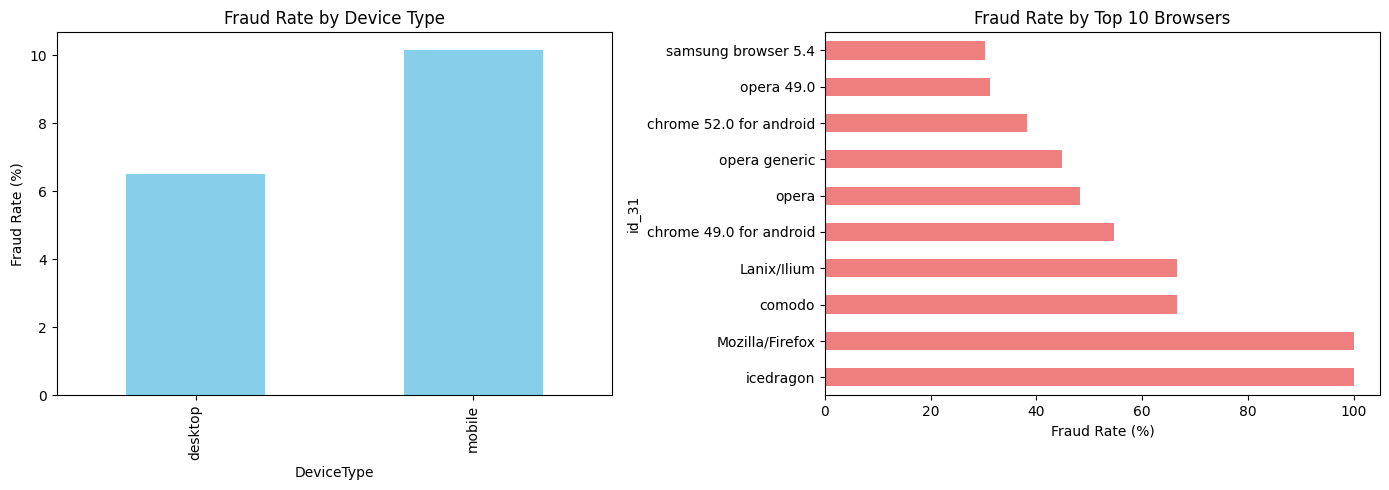

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device Type
if 'DeviceType' in df.columns:
    device_fraud = df.groupby('DeviceType')['isFraud'].mean() * 100
    device_fraud.plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Fraud Rate by Device Type')
    axes[0].set_ylabel('Fraud Rate (%)')

# Browser (id_31)
if 'id_31' in df.columns:
    browser_fraud = df.groupby('id_31')['isFraud'].mean().sort_values(ascending=False).head(10) * 100
    browser_fraud.plot(kind='barh', ax=axes[1], color='lightcoral')
    axes[1].set_title('Fraud Rate by Top 10 Browsers')
    axes[1].set_xlabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

## EDA Takeaways

- 3.5% fraud rate - heavily imbalanced, need to handle this during modeling
- Product C has 11.7% fraud rate (3x the average) - strong signal
- Discover cards show higher fraud (7.7%) vs Visa/MC (~3.4%)
- Mobile devices have higher fraud rate than desktop (10% vs 6.5%)
- Transaction amounts don't separate fraud/legit very well on their own
- Tons of missing data, especially dist1/dist2 and the V-features. Going to need a careful strategy for this.
- Some browsers show very high fraud rates but with tiny sample sizes - probably not reliable signals on their own